In [1]:
#Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Import Dataset
try:
    train_df =pd.read_csv("train.csv")
    test_df=pd.read_csv("test.csv")
except FileNotFoundError:
    print("Dataset not found")

In [3]:
print(train_df.shape)
print(test_df.shape)

(7352, 563)
(2947, 563)


In [4]:
print(train_df.head())
print(test_df.head())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

In [5]:
#Missing Value Analysis
print(train_df.isnull().sum())
print(test_df.isnull().sum())

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64
tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64


In [6]:
#Duplicate Analysis
train_df.duplicated().sum()

np.int64(0)

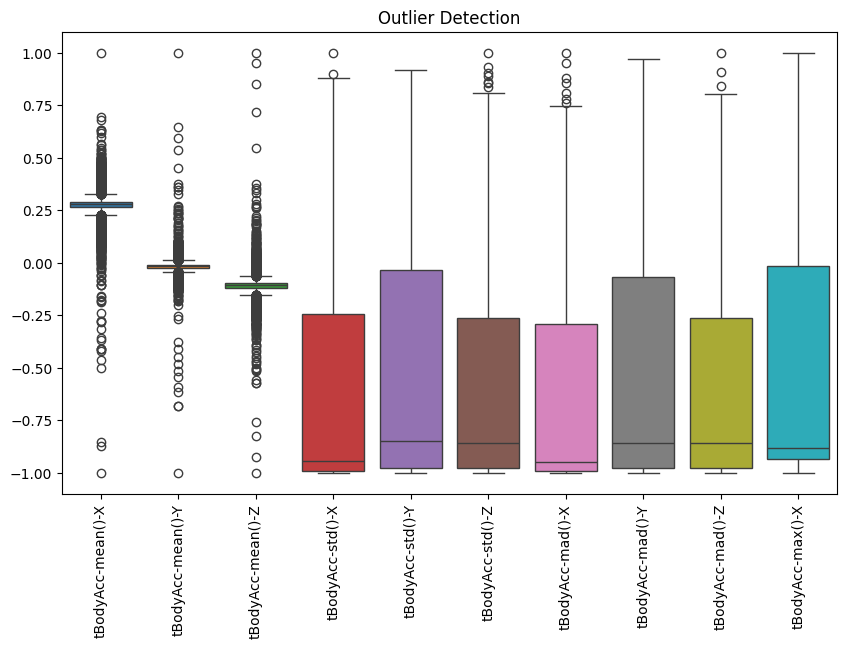

In [7]:
#Box plot for finding the outlier
plt.figure(figsize=(10,6))
sns.boxplot(data=train_df.iloc[:,0:10])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

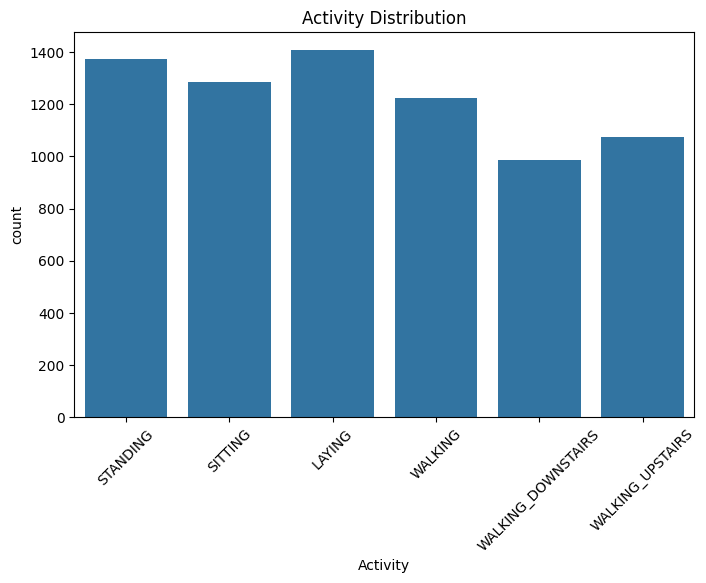

In [8]:
#Activity Distribution Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Activity', data=train_df)
plt.title("Activity Distribution")
plt.xticks(rotation=45)
plt.show()

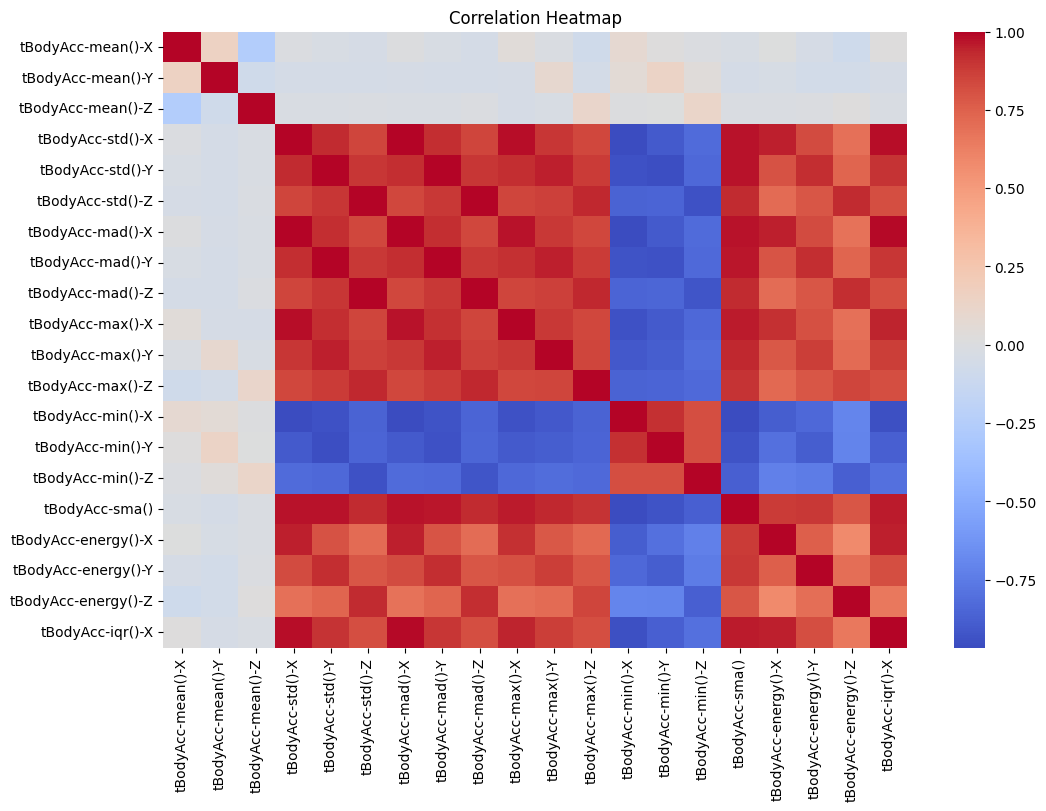

In [9]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    train_df.iloc[:, :20].corr(),
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
#Remove highly correlated features
# Correlation matrix
train_features = train_df.iloc[:,:561]
test_features = test_df.iloc[:,:561]
corr_matrix = train_features.corr().abs()

# Upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Number of features to remove:", len(to_drop))

# Remove correlated features
train_features_reduced = train_features.drop(columns=to_drop)
test_features_reduced = test_features.drop(columns=to_drop)

print("Original shape:", train_features.shape)
print("Reduced shape:", train_features_reduced.shape)

Number of features to remove: 308
Original shape: (7352, 561)
Reduced shape: (7352, 253)


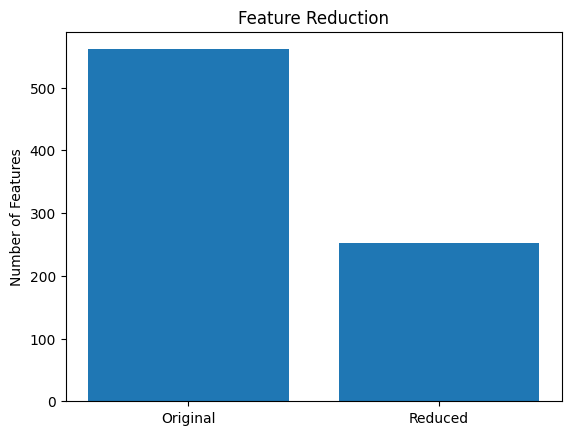

In [27]:
#Before vs After Reduction Graph
plt.bar(
    ['Original','Reduced'],
    [train_features.shape[1], train_features_reduced.shape[1]]
)

plt.ylabel("Number of Features")
plt.title("Feature Reduction")
plt.show()

In [28]:
#Confidence Interval
from scipy import stats

sample_feature = train_df.iloc[:,0]

mean = sample_feature.mean()
sem = stats.sem(sample_feature)

ci = stats.t.interval(
    confidence=0.95,
    df=len(sample_feature)-1,
    loc=mean,
    scale=sem
)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(0.27288180062998363), np.float64(0.2760944492970567))


In [29]:
#ANOVA
from scipy.stats import f_oneway

groups = []

for activity in train_df['Activity'].unique():
    groups.append(
        train_df[
            train_df['Activity']==activity
        ].iloc[:,0]
    )

f_stat,p_val = f_oneway(*groups)

print("F Statistic:",f_stat)
print("P Value:",p_val)

F Statistic: 17.626909914888536
P Value: 2.1154643414919055e-17


In [30]:
train_df["Activity"].value_counts()

Activity
0    1407
2    1374
1    1286
3    1226
5    1073
4     986
Name: count, dtype: int64

In [31]:
#Encode the Activity values
from sklearn.preprocessing import LabelEncoder
labelEncoder=LabelEncoder()
train_df['Activity']=labelEncoder.fit_transform(train_df["Activity"].values)
test_df['Activity']=labelEncoder.fit_transform(test_df["Activity"].values)

In [32]:
#Display Activity column
print(train_df["Activity"])
print(test_df['Activity'])

0       2
1       2
2       2
3       2
4       2
       ..
7347    5
7348    5
7349    5
7350    5
7351    5
Name: Activity, Length: 7352, dtype: int64
0       2
1       2
2       2
3       2
4       2
       ..
2942    5
2943    5
2944    5
2945    5
2946    5
Name: Activity, Length: 2947, dtype: int64


In [33]:
train_df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085,2.315152
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143,1.690628
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,0.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000,1.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000,2.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000,5.000000


In [34]:
#Splitting the dataset into independent and dependent datasets
train_features=train_df.iloc[:,:561]
train_target=train_df["Activity"].values
test_features=test_df.iloc[:,:561]
test_target=test_df['Activity'].values

In [35]:
#Scaling the data (feature scaling)-->makes all features come to a similar range
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train=sc.fit_transform(train_features)
X_test=sc.fit_transform(test_features)
#Y_train = np.array(train_features, dtype=np.int64)
Y_train = train_target
Y_test = test_target

In [36]:
#print data
print(X_train)
print(Y_train)

[[ 0.20064157 -0.0636826  -0.41962845 ... -0.68721921  0.40794614
  -0.00756789]
 [ 0.05594788  0.03148567 -0.25390836 ... -0.694138    0.40911698
   0.00787517]
 [ 0.07351535 -0.04341648 -0.07629468 ... -0.702239    0.4102883
   0.02650234]
 ...
 [-0.01566765  0.0167814   1.13222107 ... -0.56584847  0.64059683
   0.34870928]
 [ 0.21586648 -0.02812252 -0.86770988 ... -0.57766781  0.63147758
   0.29327564]
 [ 1.09620157  0.12919873 -1.67268082 ... -0.57392691  0.63274259
   0.33396081]]
[2 2 2 ... 5 5 5]


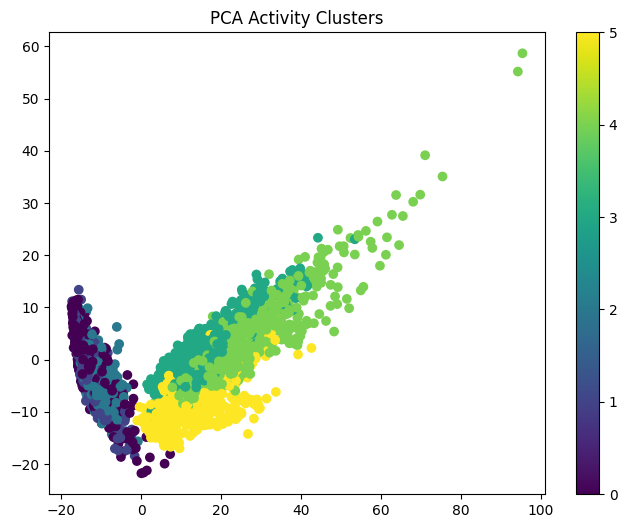

In [37]:
#Principal Component Analysis Activity Clusters
#Converting 561 dimentional data into 2 dimention 
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=Y_train,
    cmap='viridis'
)

plt.title("PCA Activity Clusters")
plt.colorbar(scatter)
plt.show()

In [38]:
#build a logistic regression classifier
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(max_iter=10000)
classifier.fit(X_train, Y_train)
# Predict
y_pred = classifier.predict(X_test)

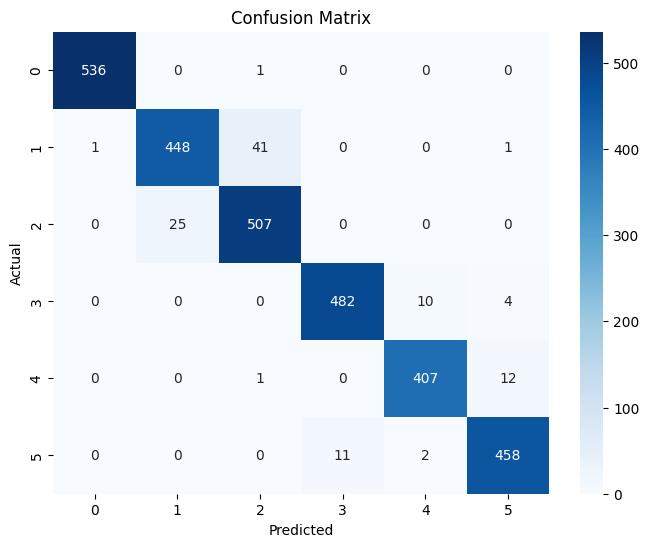

In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
#Accuracy
print("Accuracy:", accuracy_score(Y_test, y_pred))
#Classification report
print(classification_report(Y_test, y_pred))

Accuracy: 0.9630132337970818
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.95      0.91      0.93       491
           2       0.92      0.95      0.94       532
           3       0.98      0.97      0.97       496
           4       0.97      0.97      0.97       420
           5       0.96      0.97      0.97       471

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



In [41]:
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("R² Score:", r2)
print("MSE :", mse)
print("RMSE:", rmse)

R² Score: 0.9795997133259827
MSE : 0.05938242280285035
RMSE: 0.24368508941428968
